# Train a single-task regression model from scratch

In this tutorial, we train a single-task convolutional regression model to predict total coverage over ATAC-seq peaks, starting from an ATAC-seq fragment file.

In [1]:
import os
import numpy as np
import pandas as pd
import torch

## Set experiment parameters

In [2]:
experiment='tutorial_3'
if not os.path.exists(experiment):
    os.makedirs(experiment)

## Peak and fragment files

We downloaded pseudobulk scATAC data for human microglia from Corces et al. (2020): `https://www.nature.com/articles/s41588-020-00721-x`. Here, we use the `grelu.resources` module to download the fragment file and peak file from the model zoo:

In [3]:
import grelu.resources

In [4]:
# Download these datasets into local directories

fragment_file_path = grelu.resources.download_dataset(
    repo_id="Genentech/microglia-scatac-tutorial-data", filename="fragment_file.bed")

peak_file_path = grelu.resources.download_dataset(
    repo_id="Genentech/microglia-scatac-tutorial-data", filename="peak_file.narrowPeak")

In [5]:
# Paths to files
frag_file = fragment_file_path
peak_file = peak_file_path

## Set parameters

In [6]:
seq_len=2114 # Length of the input sequence
label_len=1000 # Length over which we calculate total coverage
val_chroms=["chr10"]
test_chroms=["chr11"]
genome="hg38"

## Read peak file

We read peak coordinates from the narrowPeak file.

In [7]:
import grelu.io.bed

peaks = grelu.io.bed.read_narrowpeak(peak_file)
peaks.tail(3)

,chrom,start,end,name,score,strand,signal,pvalue,qvalue,summit
83316,chrY,56870777,56870983,Microglia_full_peak_83318,94,.,3.83352,11.58170,9.41381,116
83317,chrY,56873629,56873811,Microglia_full_peak_83319,49,.,3.01171,7.02098,4.99754,105
83318,chrY,56874075,56874225,Microglia_full_peak_83320,42,.,2.86533,6.19767,4.20704,17


## Summit-center peaks

We extract the genomic coordinates for the 2114 bases surrounding the summit of each peak.

In [8]:
import grelu.data.preprocess

peaks = grelu.data.preprocess.extend_from_coord(
    peaks,
    seq_len=seq_len,
    center_col="summit"
)
peaks.tail(3)

,chrom,start,end
83316,chrY,56869836,56871950
83317,chrY,56872677,56874791
83318,chrY,56873035,56875149


## Filter peaks

We filter the peaks to include only those within autosomes. You can also use "autosomesX" or "autosomesXY" to include sex chromosomes.

In [9]:
peaks = grelu.data.preprocess.filter_chromosomes(peaks, 'autosomes')

Keeping 80823 intervals


We drop peaks that are close to ENCODE hg38 blacklist regions.

In [10]:
peaks = grelu.data.preprocess.filter_blacklist(
    peaks,
    genome=genome,
    window=50 # Remove peaks if they are within 50 bp of a blacklist region
)

Keeping 80028 intervals


## Get GC matched negative regions

To ensure that the model also learns to recognize regions that are not peaks, we will include a set of "negative" (non-peak) regions with similar GC content to the peaks.

In [11]:
negatives = grelu.data.preprocess.get_gc_matched_intervals(
    peaks,
    binwidth=0.02, # resolution of measuring GC content
    genome=genome,
    chroms="autosomes", # negative regions will also be chosen from autosomes
    seed=0,
)
negatives.head(3)

Extracting matching intervals
Filtering blacklist
Keeping 77148 intervals


,chrom,start,end
39048,chr1,801206,803320
13936,chr1,813890,816004
20216,chr1,858284,860398


We can visualize a histogram of GC content in the peaks and negative regions to verify that they are similar.

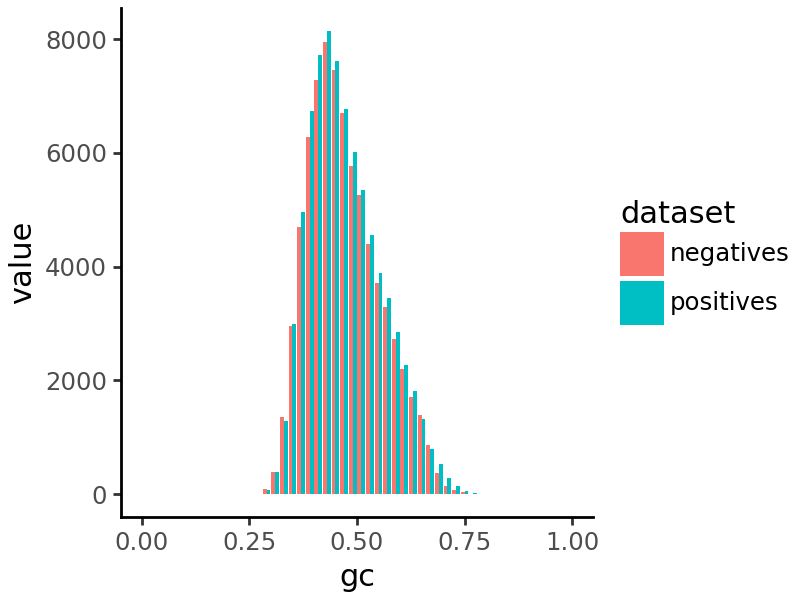

In [12]:
import grelu.visualize
grelu.visualize.plot_gc_match(
    positives=peaks, negatives=negatives, binwidth=0.02, genome="hg38", figsize=(4, 3)
)

## Combine peaks and negative regions

The full dataset includes both peaks and negative regions.

In [13]:
regions = pd.concat([peaks, negatives])
len(regions)

157176

## Make BigWig file

We convert the ATAC-seq fragment file into a bigWig file which contains the number of Tn5 insertions at each position. Note that this command requires bedtools and bedGraphToBigWig to be installed.

In [20]:
bw_file = grelu.data.preprocess.make_insertion_bigwig(
    frag_file = frag_file,
    plus_shift=0,
    minus_shift=1, # This corrects the +4/-5 Tn5 shift to a +4/-4 shift
    genome=genome,
    chroms="autosomes", # The output bigWig file contains coverage over autosomes.
)

Making bedgraph file
cat /home/lala8/.cache/huggingface/hub/datasets--Genentech--microglia-scatac-tutorial-data/snapshots/06d49b4a361b9a40e1cabf83f50030ba00a13a03/fragment_file.bed | awk -v OFS="\t" '{print $1,$2+0,$3,1000,0,"+";
    print $1,$2,$3+1,1000,0,"-"}' | sort -k1,1 | grep -e ^chr1 -e ^chr2 -e ^chr3 -e ^chr4 -e ^chr5 -e ^chr6 -e ^chr7 -e ^chr8 -e ^chr9 -e ^chr10 -e ^chr11 -e ^chr12 -e ^chr13 -e ^chr14 -e ^chr15 -e ^chr16 -e ^chr17 -e ^chr18 -e ^chr19 -e ^chr20 -e ^chr21 -e ^chr22  | bedtools genomecov -bg -5 -i stdin -g /home/lala8/.local/share/genomes/hg38/hg38.fa.sizes | bedtools sort -i stdin > ./fragment_file.bedGraph
Making bigWig file
bedGraphToBigWig ./fragment_file.bedGraph /home/lala8/.local/share/genomes/hg38/hg38.fa.sizes ./fragment_file.bw
Deleting temporary files


## Split data by chromosome

We now split the dataset by chromosome to create separate datasets for training, validation and testing.

In [21]:
train, val, test = grelu.data.preprocess.split(
    regions, val_chroms=val_chroms, test_chroms=test_chroms)

Selecting training samples
Keeping 140654 intervals


Selecting validation samples
Keeping 8115 intervals


Selecting test samples
Keeping 8407 intervals
Final sizes: train: (126394, 3), val: (699, 3), test: (791, 3)


## Make labeled datasets

We now make pytorch dataset objects in order to load paired sequences and coverage values from the genome and the bigWig file. We use the `BigWigSeqDataset` class.

We first make the training dataset. To increase model robustness we use several forms of data augmentation here: `rc=True` (reverse complementing the input sequence), `max_seq_shift=2` (shifting the coordinates of the input sequence by upto 2 bp in either direction; also known as jitter), and `max_pair_shift=20` (shifting both the input sequence and the region for which to calculate coverage by upto 20 bp in either direction).

Further, we use `label_aggfunc="sum"` which means that the label will be the summed coverage over the central region of the interval.

In [22]:
import grelu.data.dataset

In [23]:
train_ds = grelu.data.dataset.BigWigSeqDataset(
    intervals = train,
    bw_files=[bw_file],
    label_len=label_len,
    label_aggfunc="sum",
    rc=True, # reverse complement
    max_seq_shift=2, # Shift the sequence
    max_pair_shift=20, # Shift both sequence and label
    augment_mode="random",
    seed=0,
    genome=genome,
)

We do not apply any augmentations to the validation and test datasets (although it is possible to do so).

In [24]:
val_ds = grelu.data.dataset.BigWigSeqDataset(
    intervals = val,
    bw_files=[bw_file],
    label_len=label_len,
    label_aggfunc="sum", 
    genome=genome,
)

test_ds = grelu.data.dataset.BigWigSeqDataset(
    intervals = test,
    bw_files=[bw_file],
    label_len=label_len,
    label_aggfunc="sum",
    genome=genome,
)

len(train_ds), len(val_ds), len(test_ds)

(126394, 699, 791)

## Build model

In [25]:
model_params = {
    'model_type':'DilatedConvModel',
    'crop_len':(seq_len-label_len)//2,
    'n_tasks':1,
    'channels':512,
    'n_conv':8,
}

train_params = {
    'task':'regression',
    'loss': 'poisson', # Poisson loss. Other regression loss functions are "mse" and "poisson_multinomial"
    'logger':'csv',
    'lr':1e-4,
    'batch_size':512,
    'max_epochs':10,
    'devices':0,
    'num_workers':16,
    'save_dir':experiment,
}

import grelu.lightning
model = grelu.lightning.LightningModel(model_params, train_params)

## Train model

In [26]:
# See the tutorial_3 folder for logs.
trainer = model.train_on_dataset(train_ds, val_ds)

/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Ligh

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         val_loss          │       1111.22265625       │
│          val_mse          │       228985.859375       │
│        val_pearson        │   -0.36367514729499817    │
└───────────────────────────┴───────────────────────────┘

/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model        │ DilatedConvModel │  5.6 M │ train │     0 │
│ 1 │ loss         │ PoissonNLLLoss   │      0 │ train │     0 │
│ 2 │ val_metrics  │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics │ MetricCollection │      0 │ train │     0 │
│ 4 │ transform    │ Identity         │      0 │ train │     0 │
└───┴──────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.6 M                                                                                                
Total estimated model params size (MB): 22                                                                         
Modules in train mode: 118                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


## Load the best model version

In [27]:
best_checkpoint = trainer.checkpoint_callback.best_model_path
print(best_checkpoint)

tutorial_3/2026_04_03_10_18/version_0/checkpoints/epoch=9-step=2470.ckpt


In [28]:
model = grelu.lightning.LightningModel.load_from_checkpoint(best_checkpoint)

/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


## Evaluate model

We now evaluate the model's performance on the test dataset.

In [29]:
test_metrics = model.test_on_dataset(
    test_ds,
    batch_size=256,
    devices=0,
    num_workers=8
)

test_metrics

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: UserWarning: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    119.36114501953125     │
│         test_mse          │      106301.9296875       │
│       test_pearson        │     0.679975688457489     │
└───────────────────────────┴───────────────────────────┘

,test_mse,test_pearson
fragment_file,106301.929688,0.679976


## Run inference on held out sequences

We can now get the predicted total coverage for each sequence in the test set.

In [30]:
preds = model.predict_on_dataset(
    test_ds, devices=0, num_workers=8
    )
preds.shape

/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

(791, 1, 1)

We can visualize a scatter plot of predicted vs. true coverage values

/tmp/slurmjob.25072131/ipykernel_1063056/723997811.py:3: RuntimeWarning: divide by zero encountered in log
/gpfs/scratchfs01/site/u/lala8/conda/envs/grelu-test/lib/python3.10/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_pointdensity : Removed 2 rows containing non-finite values.


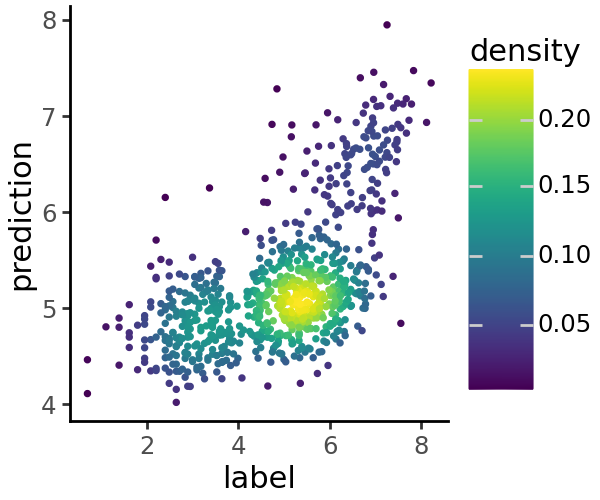

In [31]:
grelu.visualize.plot_pred_scatter(
    preds=np.log(preds),
    labels=np.log(test_ds.get_labels()),
    density=True, # Color points by local density
    figsize=(3, 2.5), # width, height
    size=.5
)